## Import Libraries

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.preprocessing import RobustScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances

## Data Loading

In [ ]:
df = pd.read_csv("data/song_recommendation.csv")

In [47]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df.head()

,Track URI,Track Name,Artist Name(s),Album Name,Album Release Date,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:6a8GbQIlV8HBUW3c6Uk9PH,I Know You Want Me (Calle Ocho),Pitbull,Pitbull Starring In Rebelution,2009-10-23,64,"dance pop,miami hip hop,pop",0.825,0.743,2.0,-5.995,1.0,0.1490,0.0142,0.000021,0.2370,0.800,127.045,4.0
1,spotify:track:70XtWbcVZcpaOddJftMcVi,From the Bottom of My Broken Heart,Britney Spears,...Baby One More Time (Digital Deluxe Version),1999-01-12,56,"dance pop,pop",0.677,0.665,7.0,-5.171,1.0,0.0305,0.5600,NaN,0.3380,0.706,74.981,4.0
2,spotify:track:72WZtWs6V7uu3aMgMmEkYe,You Can't Always Get What You Want,The Rolling Stones,Let It Bleed,1969-12-05,0,"album rock,british invasion,classic rock,rock",0.319,0.627,0.0,-9.611,1.0,0.0687,0.6750,0.000073,0.2890,0.497,85.818,4.0
3,spotify:track:4bEb3KE4mSKlTFjtWJQBqO,Don't Stop - 2004 Remaster,Fleetwood Mac,Rumours,1977-02-04,79,"album rock,classic rock,rock,soft rock,yacht rock",0.671,0.710,9.0,-7.724,1.0,0.0356,0.0393,0.000011,0.0387,0.834,118.745,4.0
4,spotify:track:0d2iYfpKoM0QCKvcLCkBao,Eastside (with Halsey & Khalid),"benny blanco, Halsey, Khalid",Eastside (with Halsey & Khalid),2018-07-12,78,"pop,electropop,etherpop,indie poptimism,pop,pop,pop r&b",0.560,0.680,6.0,-7.648,0.0,0.3210,0.5550,0.000000,0.1160,0.319,89.391,4.0


## Data Understanding and Preprocessing

### Columns in Dataset

In [48]:
df.columns

Index(['Track URI', 'Track Name', 'Artist Name(s)', 'Album Name',
       'Album Release Date', 'Popularity', 'Artist Genres', 'Danceability',
       'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness',
       'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Time Signature'],
      dtype='object')

### Check Data Dimension and Data Types

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           4999 non-null   object 
 1   Track Name          4999 non-null   object 
 2   Artist Name(s)      4999 non-null   object 
 3   Album Name          4999 non-null   object 
 4   Album Release Date  4997 non-null   object 
 5   Popularity          4999 non-null   int64  
 6   Artist Genres       4744 non-null   object 
 7   Danceability        4747 non-null   float64
 8   Energy              4997 non-null   float64
 9   Key                 4997 non-null   float64
 10  Loudness            4997 non-null   float64
 11  Mode                4997 non-null   float64
 12  Speechiness         4997 non-null   float64
 13  Acousticness        4997 non-null   float64
 14  Instrumentalness    4897 non-null   float64
 15  Liveness            4997 non-null   float64
 16  Valenc

Dataset ini terdiri dari **4.999 baris dan 19 kolom** yang memuat informasi metadata lagu serta fitur audio dari Spotify. Variabel dalam dataset **mencakup identitas lagu, popularitas, genre artis, serta berbagai karakteristik audio**.

Berdasarkan hasil pemeriksaan struktur data, **sebagian besar variabel telah tersimpan dalam tipe data yang sesuai**. Namun, kolom **Album Release Date masih bertipe object** sehingga perlu dilakukan **konversi ke tipe datetime** pada tahap preprocessing apabila akan digunakan dalam analisis berbasis waktu.

Dataset ini mengandung beberapa kolom dengan **missing values, yaitu Album Release Date, Artist Genres, Danceability, Energy, Key, Loudness, Mode, Speechiness, Acousticness, Instrumentalness, Liveness, Valence, Tempo, dan Time Signature**. Proporsi missing values pada masing-masing kolom relatif kecil dibandingkan dengan total jumlah data, sehingga penanganan missing values dapat dilakukan menggunakan **teknik imputasi**.

Selain itu, terdapat beberapa fitur yang bersifat **identifikasi atau deskriptif**, seperti **Track URI, Track Name, Artist Name(s), dan Album Name**.

### Check Duplicate

In [50]:
print("Duplicated Row : " ,df.duplicated().sum())

Duplicated Row :  13


Terdapat **13 data duplikat**.

### Check Inconsistent

In [51]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols :
  print("Total Unique Values : ", df[col].nunique())
  print(df[col].value_counts())
  print()

Total Unique Values :  4985
Track URI
spotify:track:4alHo6RGd0D3OUbTPExTHN    3
spotify:track:7mldq42yDuxiUNn08nvzHO    2
spotify:track:67eX1ovaHyVPUinMHeUtIM    2
spotify:track:0shGCs5AkhwJIgUb0SSz2B    2
spotify:track:7tFiyTwD0nx5a1eklYtX2J    2
                                       ..
spotify:track:3BSRcRHsiEy4ooWA7jw7Wg    1
spotify:track:4dim8F8t01qimHOmr6S3Gd    1
spotify:track:5PRRthP9SLfbXB359MfIWv    1
spotify:track:5xD021bM8VbqrhCVhxRozx    1
spotify:track:2skmOCFU64Bg7Ytkgwliwe    1
Name: count, Length: 4985, dtype: int64

Total Unique Values :  4476
Track Name
Sorry                                 5
Creep                                 4
Hurts So Good                         4
Heaven                                4
Pray                                  4
                                     ..
One In A Million                      1
From the Bottom of My Broken Heart    1
Still into You                        1
IDGAF                                 1
Get 'Em Girls (feat.

- **Track UR**I memiliki **4.985 nilai unik dari 4.999 data** ->  adanya **duplikasi** identitas lagu dalam dataset.

- **Track Nam**e menunjukkan jumlah nilai unik yang lebih rendah (**4.476 nilai unik**), dengan beberapa **judul lagu muncul berulang kali**. Kondisi ini wajar, karena satu judul lagu dapat dimiliki oleh artis yang berbeda.

- **Artist Name(s)** dan **Album Name** masing-masing memiliki **2.597 dan 3.854 nilai unik**, yang mencerminkan banyaknya **lagu dari artis yang sama**.

- **Album Release Date** memiliki **2.193 nilai unik** dan menunjukkan **pengulangan tanggal rilis antar lagu dalam satu album**, yang merupakan kondisi normal.

- **Artist Genres** memiliki **1.865 nilai unik** dengan **format multi-label yang beragam**, sehingga kolom ini diperlakukan sebagai **fitur deskriptif** dan **tidak digunakan secara langsung dalam pemodelan**.

Secara keseluruhan, **inkonsistensi yang ditemukan sebagian besar bersifat kontekstual dan wajar**. Penanganan data difokuskan pada penghapusan duplikasi berdasarkan Track URI, sementara pengulangan pada kolom lain dianggap wajar sesuai dengan karakteristik data musik.

### Check Invalid Values

In [52]:
df.describe()

,Popularity,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
count,4999.000000,4747.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4897.000000,4997.000000,4997.000000,4997.000000,4997.000000
mean,38.062813,0.607982,0.682576,5.145687,-7.250565,0.694016,0.065305,0.209230,0.027476,0.185169,0.582875,121.731560,3.961177
std,29.501712,0.145108,0.191331,3.566646,3.242031,0.460869,0.062490,0.249858,0.118880,0.147856,0.238784,26.244455,0.262581
min,0.000000,0.000000,0.000020,0.000000,-29.368000,0.000000,0.000000,0.000009,0.000000,0.018500,0.000000,0.000000,0.000000
25%,0.000000,0.516000,0.557000,2.000000,-9.050000,0.000000,0.032900,0.018200,0.000000,0.089200,0.396000,103.005000,4.000000
50%,43.000000,0.616000,0.714000,5.000000,-6.554000,1.000000,0.042700,0.092900,0.000006,0.128000,0.594000,120.853000,4.000000
75%,64.000000,0.708000,0.834000,8.000000,-4.868000,1.000000,0.066800,0.323000,0.000515,0.245000,0.778000,134.797000,4.000000
max,98.000000,0.984000,0.997000,11.000000,-0.276000,1.000000,0.711000,0.987000,0.973000,0.982000,0.991000,213.654000,5.000000


Variabel **Tempo dan Time Signature** menunjukkan **nilai minimum 0,** yang secara musikal **tidak realistis**. Nilai tersebut diidentifikasi sebagai **nilai tidak valid** dan akan ditangani pada tahap preprocessing. Selebihnya, tidak ditemukan nilai ekstrem yang sepenuhnya tidak masuk akal pada sebagian besar fitur.

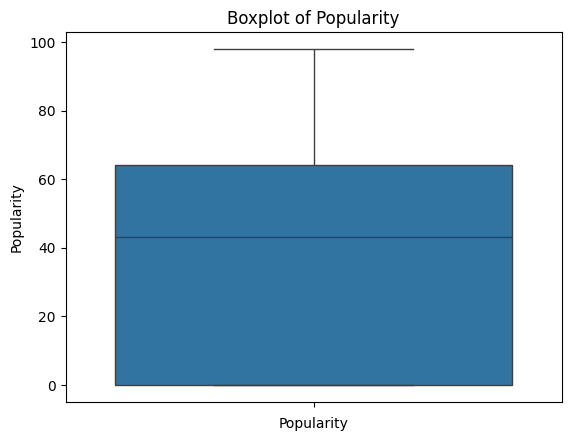

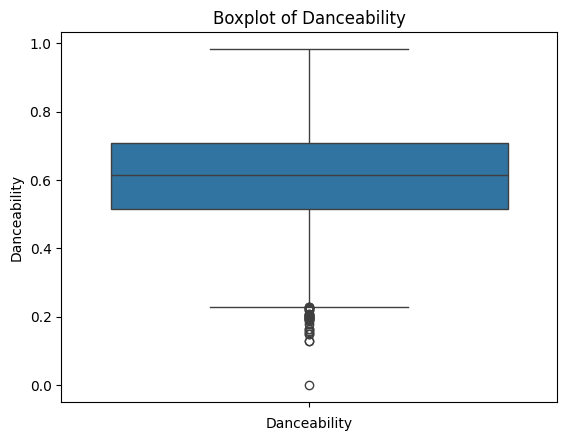

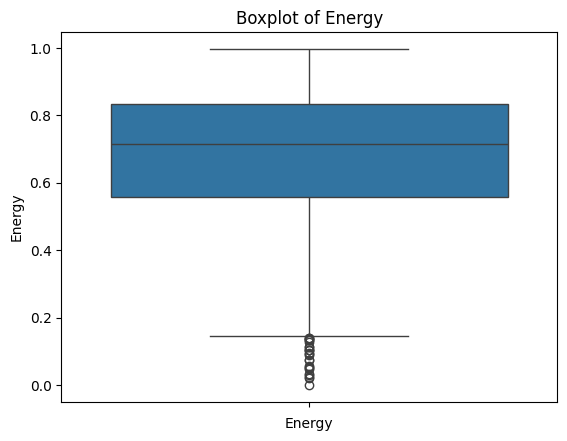

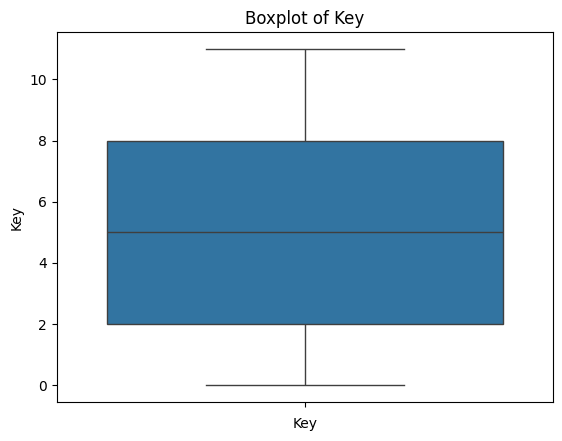

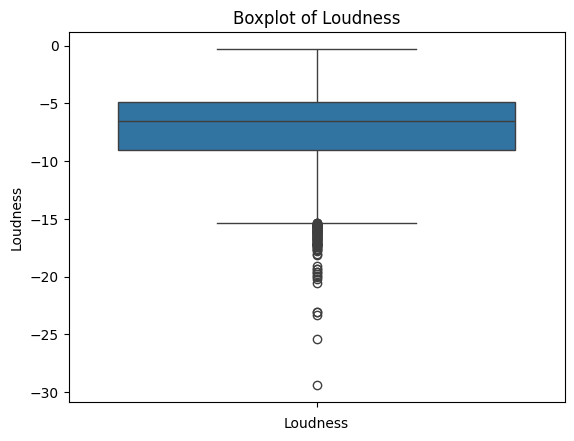

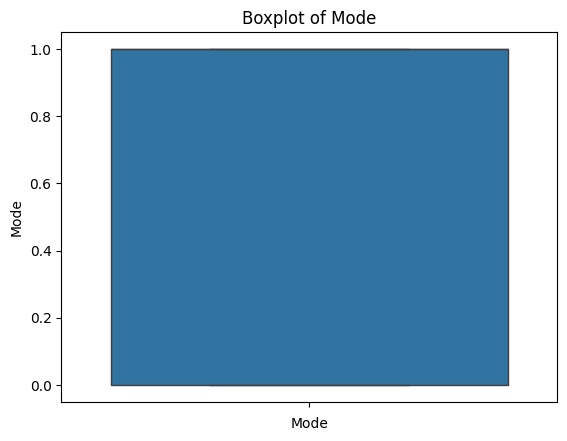

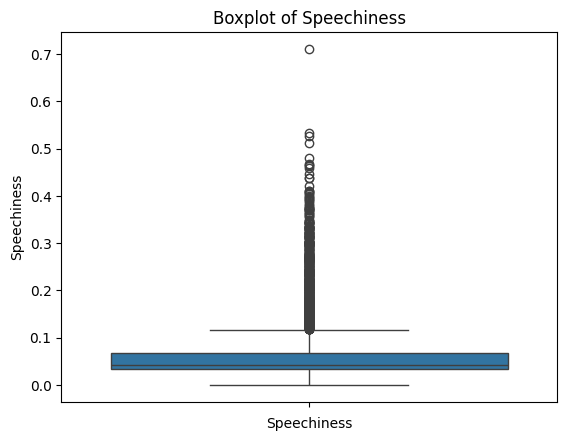

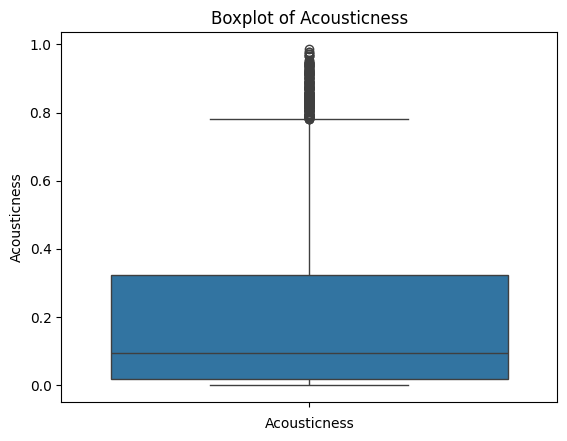

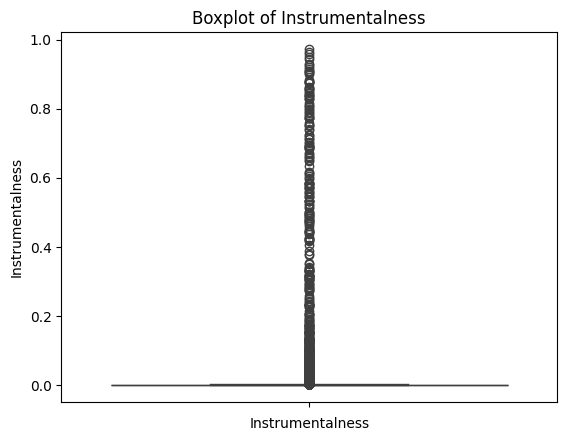

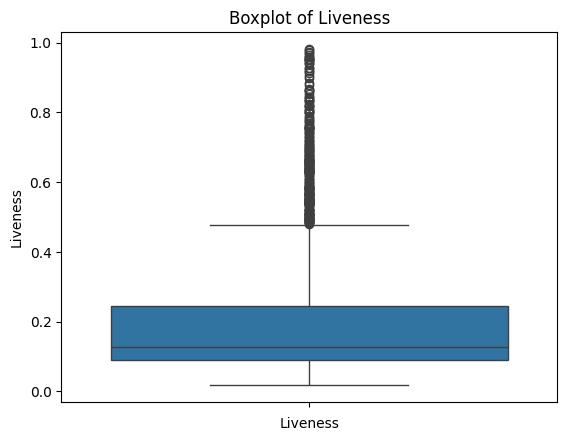

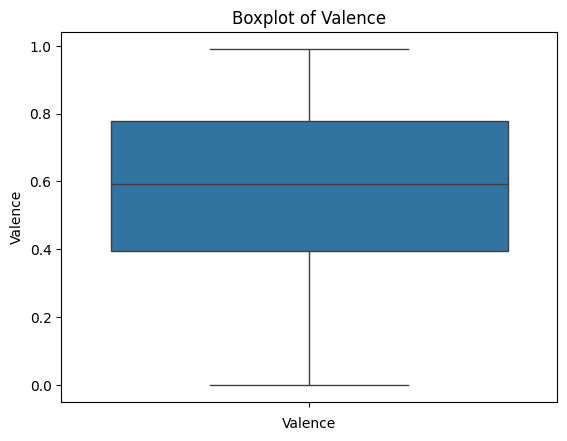

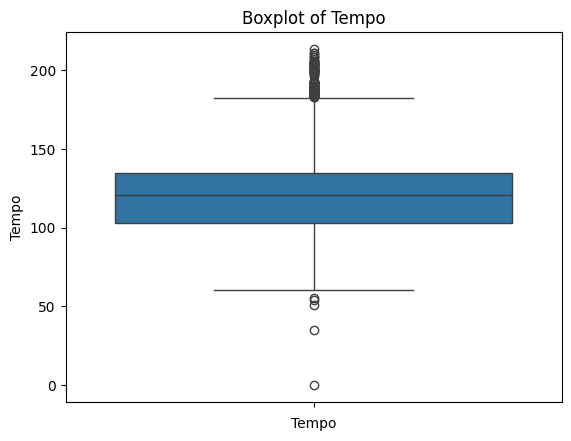

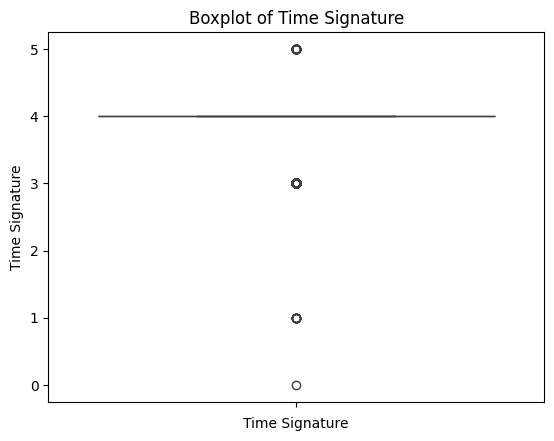

In [53]:
num_cols = df.select_dtypes(exclude=['object']).columns

for col in num_cols :
  sns.boxplot(y = df[col])
  plt.title(f'Boxplot of {col}')
  plt.xlabel(col)
  plt.show()

**Outlier yang teridentifikasi** pada boxplot **sebagian besar merupakan outlier alami (natural outliers)** yang masih berada **dalam rentang valid** sesuai domain musik Spotify. Tidak ditemukan indikasi invalid values numerik yang memerlukan penghapusan.

### Handling Invalid Values

In [54]:
df.loc[df['Tempo'] == 0, 'Tempo'] = np.nan
df.loc[df['Time Signature'] == 0, 'Time Signature'] = np.nan

**Nilai 0 pada variabel Tempo dan Time Signature diidentifikasi sebagai nilai yang tidak valid** secara musikal, karena tempo dan tanda birama tidak mungkin bernilai nol. Oleh karena itu, nilai tersebut **dikonversi menjadi NaN** agar dapat **diperlakukan sebagai missing values** dan ditangani secara tepat pada tahap imputasi selanjutnya.

### Handling Duplicates

In [55]:
df = df.drop_duplicates(subset=['Track URI'], keep='first')

**Duplikasi data berdasarkan Track URI diidentifikasi sebagai inkonsistensi**, mengingat Track URI merepresentasikan **identitas unik setiap lagu** pada Spotify. Untuk **mencegah bias** dalam analisis dan pemodelan rekomendasi, **data duplikat dihapus** dengan mempertahankan satu representasi lagu saja.

### Handling Data Type

In [56]:
df['Album Release Date'].dropna().astype(str).str.len().value_counts()

,count
Album Release Date,
10,4270
4,693
7,20


Pemeriksaan lanjutan terhadap kolom **Album Release Date** **menunjukkan adanya ketidakkonsistenan format penulisan tanggal**. Berdasarkan analisis panjang string, **sebagian besar data menggunakan format tanggal lengkap (YYYY-MM-DD, 4.270 data)**, sementara **sebagian lainnya hanya mencantumkan tahun saja (YYYY, 693 data) dan tahun–bulan (YYYY-MM, 20 data)**.

In [57]:
df['Release Year'] = df['Album Release Date'].str[:4]
df['Release Year'] = pd.to_numeric(df['Release Year'], errors='coerce')

In [58]:
df = df.drop(columns=['Album Release Date'])

Untuk menjaga **konsistensi data dan menghindari asumsi tanggal yang tidak tersedia**, informasi tanggal rilis **distandarisasi dengan mengekstraksi tahun rilis (Release Year) dari kolom Album Release Date**. Pendekatan ini mempertahankan informasi temporal yang paling stabil dan relevan, serta memastikan bahwa nilai yang tidak dapat dikonversi ditangani sebagai missing values secara konsisten.

### Check Missing Values

In [59]:
df.isnull().sum()

,0
Track URI,0
Track Name,0
Artist Name(s),0
Album Name,0
Popularity,0
Artist Genres,255
Danceability,252
Energy,2
Key,2
Loudness,2


Kolom **Artist Genres** memiliki jumlah **missing values paling banyak (255 data), diikuti oleh Danceability (252 data) dan Instrumentalness (101 data)**. Sementara itu, sebagian besar fitur audio lainnya seperti **Energy, Key, Loudness, Mode, Speechiness, Acousticness, Liveness, Valence, Tempo, dan Time Signature hanya memiliki jumlah missing values yang sangat kecil**.

Kolom **Album Release Date dan Release Year masing-masing mengandung 2 nilai hilang, yang berasal dari data dengan format tanggal yang tidak dapat diinterpretasikan**. Secara keseluruhan, proporsi **missing values relatif kecil** dibandingkan dengan total jumlah data, sehingga penanganannya dapat dilakukan menggunakan **teknik imputasi** tanpa mengurangi kualitas dan representativitas dataset.

### Handling Missing Values

In [60]:
df['Artist Genres'] = df['Artist Genres'].fillna('unknown')

**Missing values pada kolom Artist Genres** diisi dengan label "**unknown**" untuk merepresentasikan **ketidaktersediaan informasi genre secara eksplisit**, **menghindari bias** akibat imputasi kategori dominan, serta memastikan kompatibilitas dengan proses encoding pada tahap selanjutnya.

In [61]:
numerical_cols = ['Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness',
                  'Liveness', 'Valence', 'Tempo', 'Time Signature', 'Release Year']

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

**Missing values pada fitur numerik ditangani menggunakan median imputation** untuk menjaga kestabilan distribusi data dan mengurangi pengaruh outlier.

### Handling Meaningless Features

In [62]:
identifier_cols = ['Track URI', 'Track Name', 'Artist Name(s)', 'Album Name']

In [63]:
df_model = df.drop(columns=identifier_cols)

## EDA

### Correlation Between Numerical Features

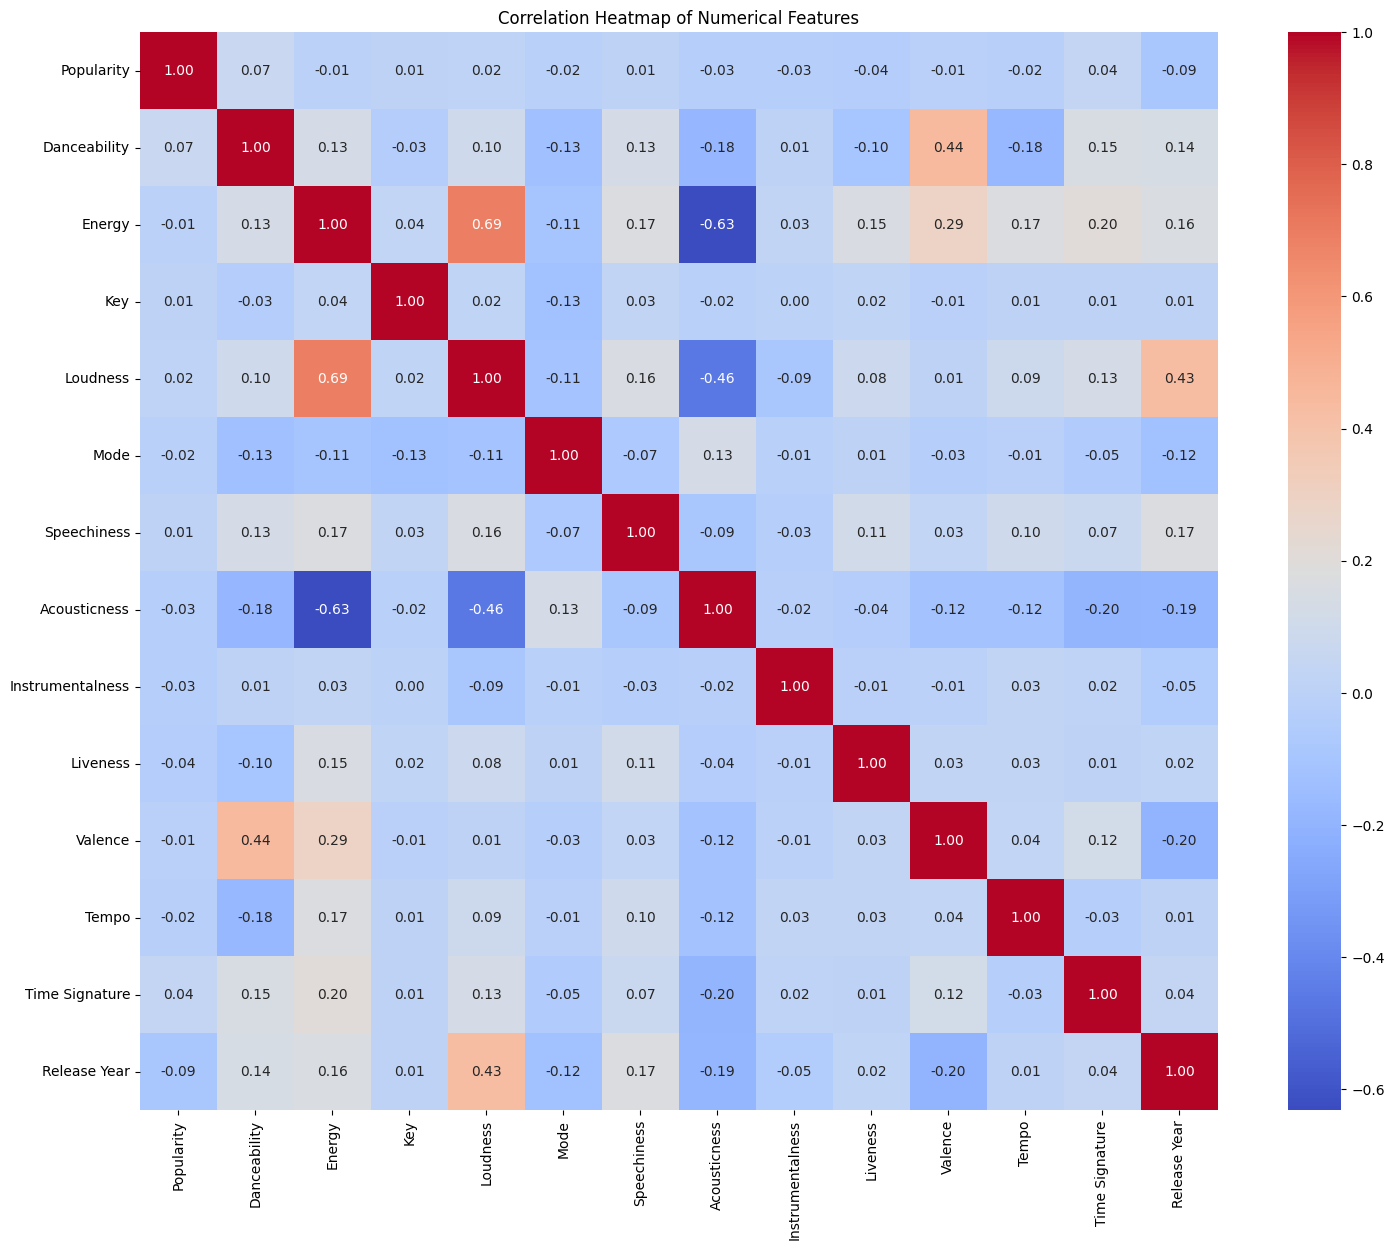

In [64]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = num_cols.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

- Korelasi positif yang paling menonjol terlihat antara **Energy dan Loudness (≈ 0.69)**. Hal ini sesuai dengan karakteristik musikal, di mana **lagu dengan tingkat energi tinggi cenderung diproduksi dengan volume yang lebih keras**.
- Sebaliknya, **Loudness dan Acousticness (≈ -0.46)** menunjukkan korelasi negatif yang cukup kuat, mengindikasikan bahwa **lagu yang bersifat akustik umumnya memiliki tingkat loudness yang lebih rendah** dibandingkan lagu elektronik atau heavily produced.
- Selain itu, **Energy** dan **Acousticness** juga memiliki **korelasi negatif yang signifikan (≈ -0.63)**, yang menunjukkan bahwa **lagu akustik cenderung memiliki energi yang lebih rendah**.
- Korelasi moderat ditemukan antara **Danceability** dan **Valence** **(≈ 0.44)**, menandakan bahwa **lagu yang lebih mudah untuk ditarikan cenderung memiliki nuansa emosional yang lebih positif atau ceria**.
- **Release Year** menunjukkan **korelasi positif sedang dengan Loudness (≈ 0.43)**, mengindikasikan bahwa **lagu-lagu yang dirilis pada tahun yang lebih baru cenderung memiliki loudness yang lebih tinggi**.

Fitur-fitur seperti **Key, Mode, Instrumentalness, dan Liveness menunjukkan korelasi yang sangat rendah** dengan fitur lain, menandakan bahwa **fitur tersebut memberikan informasi unik dan tidak redundan**. Tidak ditemukan korelasi yang sangat tinggi atau mendekati sempurna antar fitur, sehingga **seluruh fitur numerik tetap relevan untuk digunakan** dalam tahap pemodelan.

### Correlation Between Categorical Features

In [65]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

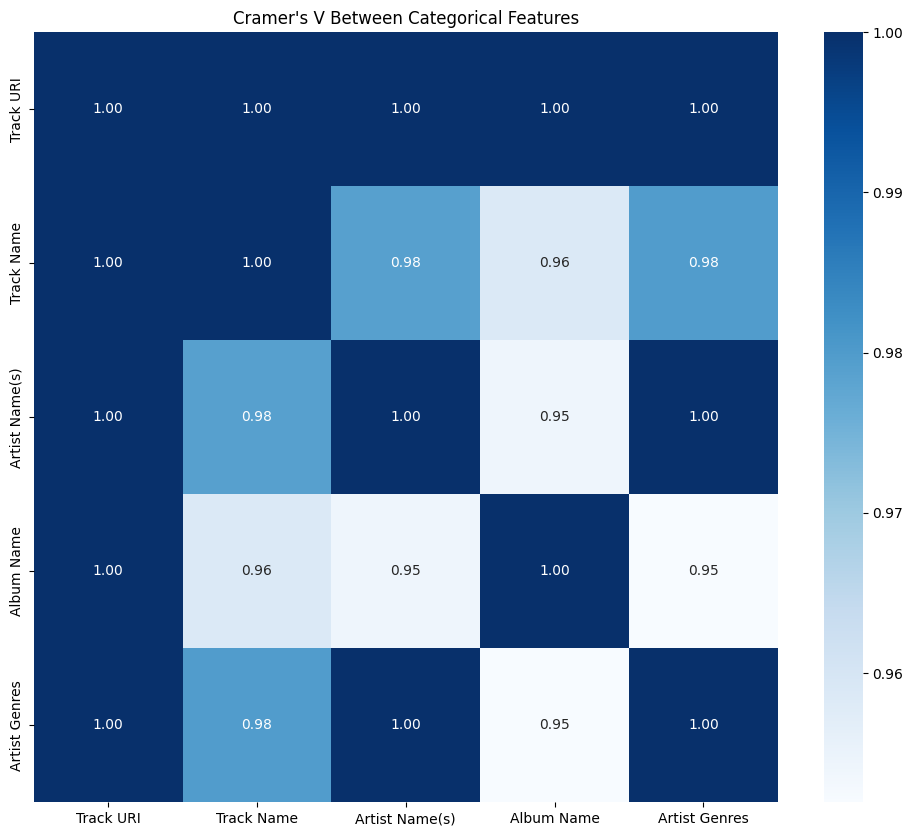

In [66]:
cat_cols = df.select_dtypes(include=["object"]).columns

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

plt.figure(figsize=(12, 10))
sns.heatmap(cramers_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Cramer's V Between Categorical Features")
plt.show()

Hasil analisis Cramér’s V menunjukkan adanya **asosiasi yang sangat kuat antar fitur kategorikal**, dengan sebagian besar pasangan memiliki **nilai mendekati 1**. Hal ini mengindikasikan bahwa **fitur-fitur tersebut bersifat saling bergantung dan berperan sebagai identifier**, bukan sebagai representasi karakteristik konten musik. Oleh karena itu, **fitur kategorikal tersebut dikeluarkan dari proses pemodelan utama** untuk menghindari redundansi dan bias dalam sistem rekomendasi.

### Distribution

In [67]:
continuous_cols = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness',
                   'Liveness', 'Valence', 'Tempo']
count_cols = ['Key', 'Mode', 'Time Signature', 'Release Year']

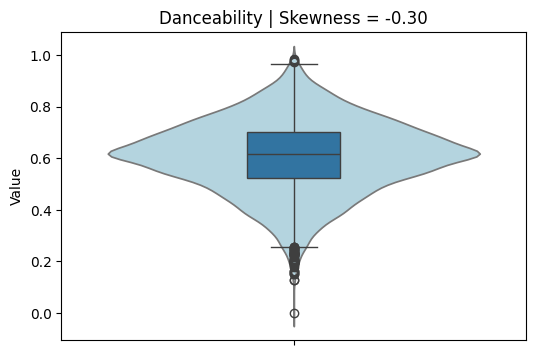

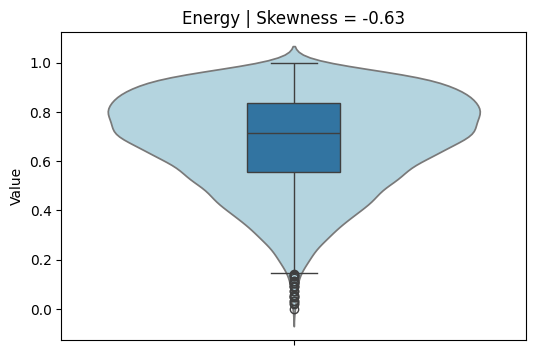

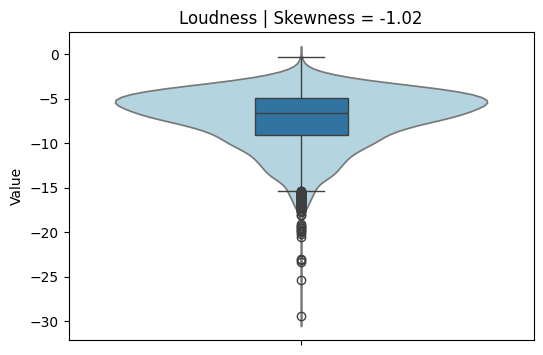

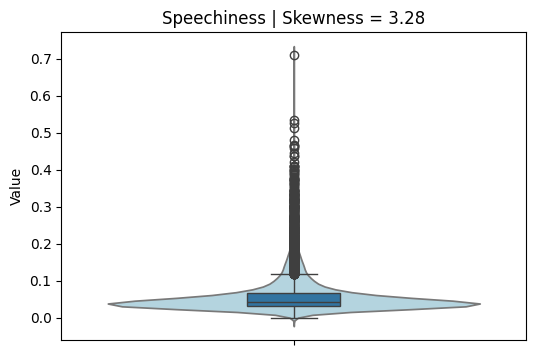

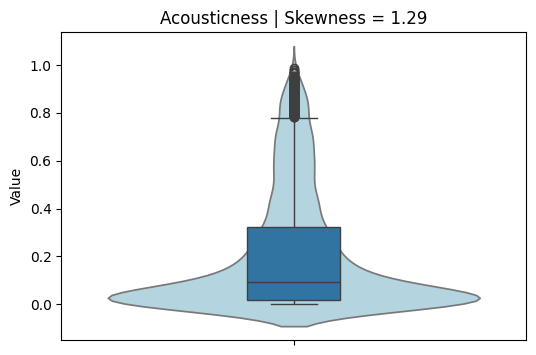

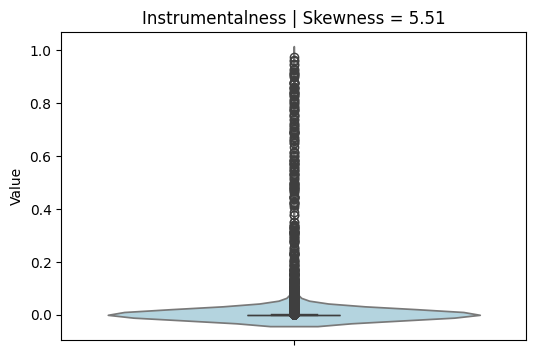

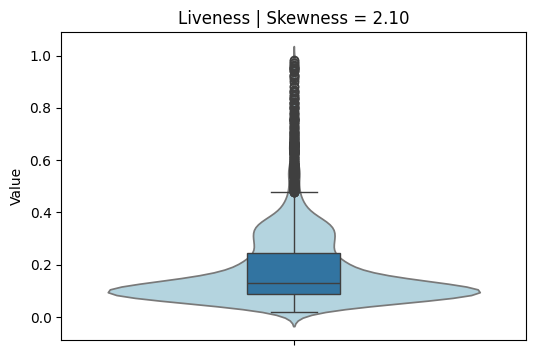

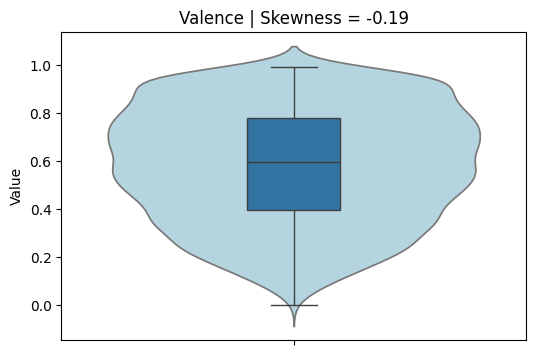

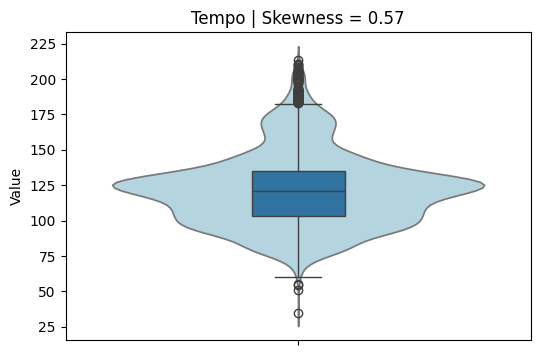

In [68]:
for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(y=df[col], inner=None, color="lightblue")
    sns.boxplot(y=df[col], width=0.2)
    plt.title(f"{col} | Skewness = {df[col].skew():.2f}")
    plt.ylabel("Value")
    plt.show()

Banyak **fitur audio menunjukkan distribusi skewed dan outlier**, terutama pada **speechiness, instrumentalness, dan liveness.** Outlier yang terdeteksi **tidak dianggap anomali**, melainkan mencerminkan **keragaman karakteristik musik**.

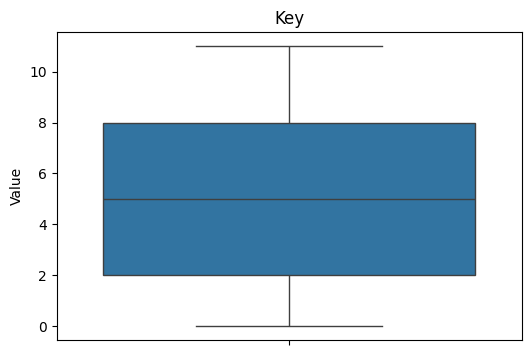

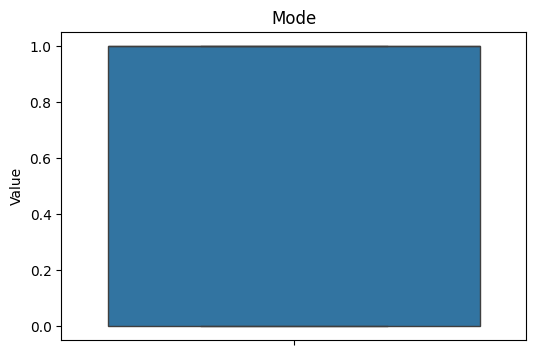

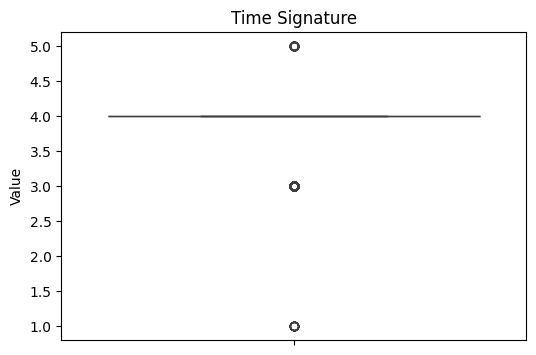

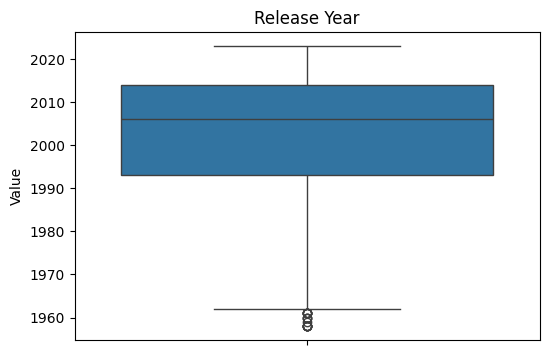

In [69]:
for col in count_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel("Value")
    plt.show()

Outlier yang muncul pada **Time Signature dan Release Year bersifat informatif**, bukan kesalahan data, sehingga fitur-fitur ini **tidak memerlukan penghapusan outlier**.

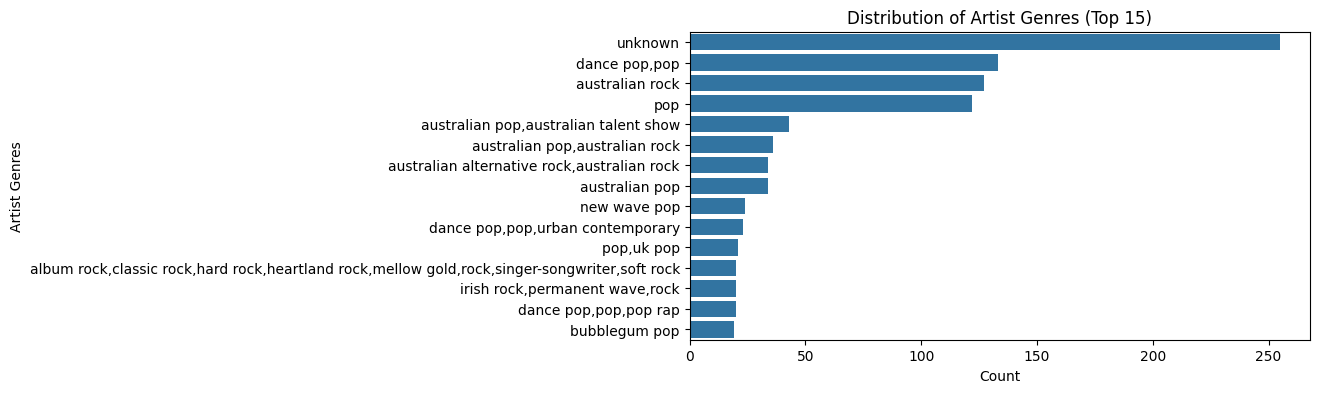

In [70]:
cat_cols = ['Artist Genres']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().head(15).index)
    plt.title(f'Distribution of {col} (Top 15)')
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

Kategori **“unknown”** memiliki **frekuensi tertinggi**, yang **mengindikasikan adanya data genre yang tidak tersedia atau hasil imputasi dari missing values**. Hal ini wajar dan perlu diperhatikan karena kategori ini bersifat kurang informatif secara semantik.

Genre populer seperti **“dance pop,pop”, “pop”, dan “australian rock” mendominasi distribusi**, mencerminkan bahwa dataset sangat **terfokus pada musik populer arus utama**. Sebagian besar **genre lainnya memiliki frekuensi rendah**, menandakan **keragaman genre tetapi dengan representasi yang tidak seimbang**.

## Feature Selection

In [71]:
audio_features = ['Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness',
                  'Liveness', 'Valence', 'Tempo', 'Time Signature']

- **Fitur audio** didasarkan pada **tujuan utama sistem**, yaitu **mengukur kemiripan antar lagu berdasarkan karakteristik audio intrinsik**.
- **Track URI, Track Name, Artist Name(s), dan Album Name tidak digunakan** karena berperan sebagai **identifier unik atau informasi deskriptif**. Fitur-fitur ini **tidak merepresentasikan karakteristik musikal lagu** dan tidak memiliki makna numerik untuk perhitungan similarity.
- **Artist Genres** sempat dipertimbangkan sebagai fitur tambahan. Namun, hasil EDA menunjukkan **distribusi yang sangat tidak seimbang** dengan **dominasi nilai unknown** serta **banyak genre dengan frekuensi sangat kecil**. Selain itu, genre bersifat artist-level dan tidak selalu mencerminkan karakteristik audio pada level lagu. Oleh karena itu, fitur ini tidak disertakan agar sistem rekomendasi tetap fokus pada kemiripan audio yang lebih objektif dan konsisten.

## Scaling

In [72]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_model[audio_features])

**Feature scaling** dilakukan menggunakan **RobustScaler** untuk **menormalkan** fitur audio dengan tetap **mempertahankan ketahanan terhadap outlier**. Metode ini dipilih karena sebagian besar fitur audio menunjukkan keberadaan outlier, sehingga scaling berbasis median dan IQR lebih sesuai untuk menjaga stabilitas perhitungan.

## Compute Similarity

In [73]:
similarity_matrix = cosine_similarity(X_scaled)

## Build Recommendation Function

In [90]:
def recommend_songs(track_name, df, similarity_matrix, top_n=5):
    # cari semua lagu dengan judul yang sama
    idx_list = df[df['Track Name'].str.lower() == track_name.lower()].index

    if len(idx_list) == 0:
        return "Track not found"

    # ambil satu lagu sebagai representatif
    idx = idx_list[0]

    input_track = df.loc[idx, 'Track Name'].lower()
    input_artist = df.loc[idx, 'Artist Name(s)'].lower()

    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    recommendations = []
    seen = set()

    for i, score in sim_scores:
        track = df.iloc[i]['Track Name']
        artist = df.iloc[i]['Artist Name(s)']

        key = (track.lower(), artist.lower())

        # buang hanya lagu input yang IDENTIK
        if key == (input_track, input_artist):
            continue

        # buang duplikat rekomendasi
        if key in seen:
            continue

        recommendations.append((track, artist))
        seen.add(key)

        if len(recommendations) == top_n:
            break

    return pd.DataFrame(recommendations, columns=['Track Name', 'Artist Name(s)'])

Fungsi **recommend_songs** merupakan **content-based recommendation system yang menerima** satu input berupa **judul lagu** dan **mengembalikan lima lagu rekomendasi** berdasarkan kemiripan fitur audio. Fungsi ini terlebih dahulu **mencari lagu dengan judul yang sesuai**, lalu **memilih satu lagu sebagai representatif** untuk **menghitung cosine similarity terhadap seluruh lagu lain**. Lagu-lagu kemudian **diurutkan dari yang paling mirip**, dengan mekanisme filter untuk menghindari lagu input itu sendiri serta menghilangkan duplikasi judul–artis pada hasil rekomendasi. Hasil akhir berupa **lima lagu unik yang memiliki karakteristik audio paling mirip** dengan lagu input.

## Inputs to the Function and Examine

In [118]:
recommend_songs("Jealous", df, similarity_matrix)

,Track Name,Artist Name(s)
0,Can I Be Him,James Arthur
1,Out Of Reach,GABRIELLE
2,Memories,Maroon 5
3,I Heard It Through The Grapevine - Single Version (Mono),Marvin Gaye
4,Wherever I Lay My Hat (That's My Home),Paul Young


**Lagu Jealous** dikenal sebagai **lagu pop ballad dengan tempo sedang, emosi kuat, dan danceability serta valence rendah–menengah**. Rekomendasi yang diberikan juga didominasi oleh **lagu-lagu slow hingga mid-tempo, bernuansa emosional dan soulful**. Hal ini menunjukkan bahwa sistem berhasil menangkap **kemiripan karakteristik audio, khususnya pada aspek energy, tempo, dan valence**.

In [140]:
recommend_songs("Side To Side", df, similarity_matrix)

,Track Name,Artist Name(s)
0,Real Love,"Clean Bandit, Jess Glynne"
1,She's so Mean,Matchbox Twenty
2,Shut Up and Dance,WALK THE MOON
3,Where Them Girls At (feat. Nicki Minaj & Flo Rida),David Guetta
4,Booty,"Jennifer Lopez, Iggy Azalea"


**Side To Side** merupakan **lagu dance-pop dengan tempo tinggi, danceability dan energy tinggi**. Rekomendasi yang dihasilkan sebagian besar adalah **lagu-lagu upbeat, pop/dance, dan club-oriented**, yang memiliki karakteristik audio serupa seperti **tempo cepat dan energi tinggi**. Ini menunjukkan bahwa **sistem konsisten dalam merekomendasikan lagu dengan profil ritmis yang sebanding**.

In [141]:
recommend_songs("Shape of You", df, similarity_matrix)

,Track Name,Artist Name(s)
0,Don't Wait Up,Shakira
1,Be Mine,Ofenbach
2,Dance with Me,Debelah Morgan
3,What Do You Mean?,Justin Bieber
4,Circus - Remastered,Britney Spears


**Shape of You** memiliki ciri khas **mid-tempo pop dengan groove kuat, danceability tinggi, dan energy sedang**. Lagu-lagu rekomendasinya juga memiliki **nuansa pop yang catchy dan rhythm-driven**, menunjukkan bahwa sistem berhasil menangkap **kesamaan dalam danceability, tempo, dan overall mood meskipun berasal dari artis yang berbeda**.